__ISING MODEL SIMULATION WITH EXTERNAL FIELD h__  

The previous simulation shows the dynamic of opinion dynamics consists of positive(+1), negative(-1), and neutral (0) sentiment on different temperature conditions. In this section, we add the presence of external field. External field (h) is extracted from mainstream media consists of positive, negative, and neutral media. We calculate the magnetization of h and substitute it to the Ising Model equation.
The data used in this model is collected from our confidential daily opinion recap file. We use the data on August 1st 2026 

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(N_up_initial, N_down_initial, N_o, T, h_up,
                               h_down, h_o, J, q, steps):
# 1. INITIALIZATION
    N = N_up_initial + N_down_initial + N_o
    h = h_up + h_down + h_o                  #Add external field
    # Probability of each initial opinion
    P_up = N_up_initial / N
    P_down = N_down_initial / N
    P_neutral = N_o / N

    # Initial magnetization
    M_awal = (N_up_initial - N_down_initial) / N
    h_initial = (h_up-h_down) / h            #Magnetization of external field

    print("INITIAL SPIN CONDITION")
    print(f"Total Population (N) : {N}")
    print(f"Probability +1       : {P_up:.4f}")
    print(f"Probability -1       : {P_down:.4f}")
    print(f"Probability 0        : {P_neutral:.4f}")
    print(f"Initial M            : {M_awal:.4f}")
    print(f"Initial h            : {h_initial:.4f}\n")
    

    # Assign spins according to observed initial counts
    spins = np.array([1] * N_up_initial + [-1] * N_down_initial + [0] * N_o)

    np.random.shuffle(spins)

    # Initial population counts
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    N_neutral = np.sum(spins == 0)

    print("RANDOM ASSIGN SPIN CONDITION")
    print(f"N_up       : {N_up}")
    print(f"N_down     : {N_down}")
    print(f"N_neutral  : {N_neutral}")
    print(f"Actual M   : {(N_up - N_down) / N:.4f}\n")

# 2. GLAUBER + MEAN-FIELD SIMULATION
    magnetization_history = []
    N_up_history = []
    N_down_history = []
    N_neutral_history = []
    spin_history = []
    kB = 0.6

    spin_history.append(spins.copy())
    for step in range(steps):
        for _ in range(N):                   # N spin-update attempts = 1 Monte Carlo Step (MCS)
            M = (N_up - N_down) / N          # Current magnetization
            h_eff = h_initial + J * q * M            # Mean-field effective field  
            
            i = np.random.randint(0, N)      # Select random spin
            sigma_old = spins[i]

            # CASE 1: CURRENT SPIN = +1: +1 can stay +1 OR change to -1
            if sigma_old == 1:
                sigma_new = -1

                E_old = -sigma_old * h_eff   # Energy of old and new states
                E_new = -sigma_new * h_eff
                delta_E = E_new - E_old      # Energy Difference

                exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))  # Glauber probability
                P_transition = 1.0 / (1.0 + exp_term)
                
                r = np.random.rand()         # Accept/reject
                if r < P_transition:
                    sigma_final = -1
                else:
                    sigma_final = 1

            # CASE 2: CURRENT SPIN = -1: -1 can stay -1 OR change to +1
            elif sigma_old == -1:
                sigma_new = 1

                E_old = -sigma_old * h_eff   # Energy of old and new states
                E_new = -sigma_new * h_eff
                delta_E = E_new - E_old      # Energy Difference

                exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))   # Glauber probability
                P_transition = 1.0 / (1.0 + exp_term)

                r = np.random.rand()         # Accept/reject
                if r < P_transition:
                    sigma_final = 1
                else:
                    sigma_final = -1

            # CASE 3: CURRENT SPIN = 0; Neutral can: 0 -> 0, 0 -> +1, 0 -> -1
            # Candidate states are tested in random order. The FIRST accepted candidate becomes the final state.
            else:
                candidates = [0, 1, -1]
                np.random.shuffle(candidates)       # Randomize candidate order
                sigma_final = 0                     # Default: remain neutral

                for sigma_new in candidates:        # Energy of old and candidate state
                    E_old = -sigma_old * h_eff
                    E_new = -sigma_new * h_eff
                    delta_E = E_new - E_old
                    
                    exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100)) # Glauber probability
                    P_transition = 1.0 / (1.0 + exp_term)

                    r = np.random.rand()       # Accept/reject

                    if r < P_transition:

                        sigma_final = sigma_new
                        break

# 3. UPDATE POPULATION COUNTS
            if sigma_final != sigma_old:
                if sigma_old == 1:       # Remove old state
                    N_up -= 1
                elif sigma_old == -1:
                    N_down -= 1
                elif sigma_old == 0:
                    N_neutral -= 1

                if sigma_final == 1:     # Add new state
                    N_up += 1
                elif sigma_final == -1:
                    N_down += 1
                elif sigma_final == 0:
                    N_neutral += 1
                
                spins[i] = sigma_final    # Update spin

        # Store magnetization after one MCS
        M_current = (N_up - N_down) / N
        magnetization_history.append(M_current)
        N_up_history.append(N_up)
        N_down_history.append(N_down)
        N_neutral_history.append(N_neutral)
        spin_history.append(spins.copy())
    return (magnetization_history, N_up_history, N_down_history, N_neutral_history, spin_history)

# SIMULATION PARAMETERS
Data_N_up = 1424
Data_N_down = 1106 
Data_N_neutral = 198
h_up = 1413
h_down = 137
h_o = 350
J_coupling = 0.3
q_neighbors = 4.0
Time_steps = 200
Temperature = 2.0

# RUN SIMULATION
np.random.seed(42)
M_history, N_up_history, N_down_history, N_neutral_history, spin_history = simulate_glauber_with_data(N_up_initial=Data_N_up, 
    N_down_initial=Data_N_down, N_o=Data_N_neutral, h_up=h_up, h_down=h_down, h_o=h_o, T=Temperature, J=J_coupling, q=q_neighbors, steps=Time_steps)


INITIAL SPIN CONDITION
Total Population (N) : 2728
Probability +1       : 0.5220
Probability -1       : 0.4054
Probability 0        : 0.0726
Initial M            : 0.1166
Initial h            : 0.6716

RANDOM ASSIGN SPIN CONDITION
N_up       : 1424
N_down     : 1106
N_neutral  : 198
Actual M   : 0.1166



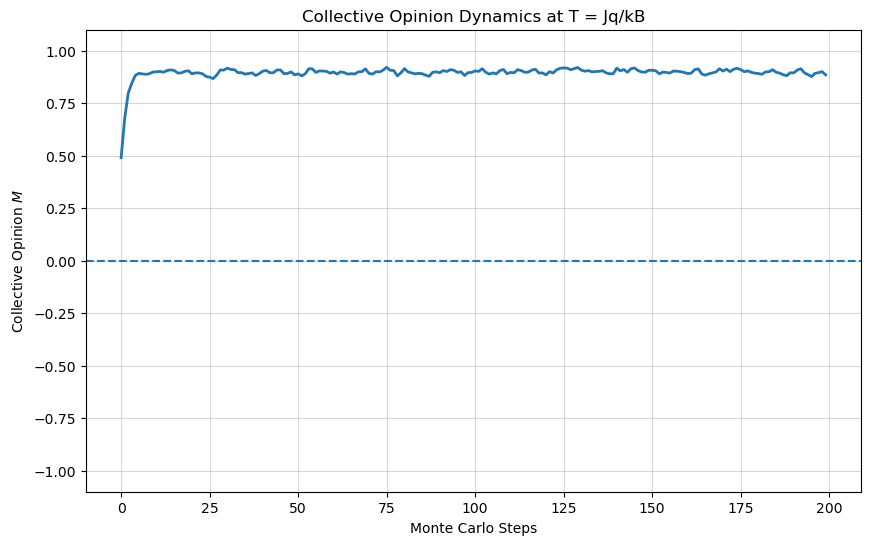

In [32]:
#MAGNETIZATION AS COLLECTIVE OPINION PLOT
plt.figure(figsize=(10, 6))
plt.plot(M_history, linewidth=2)
plt.title("Collective Opinion Dynamics at T = Jq/kB")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Collective Opinion $M$")
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()

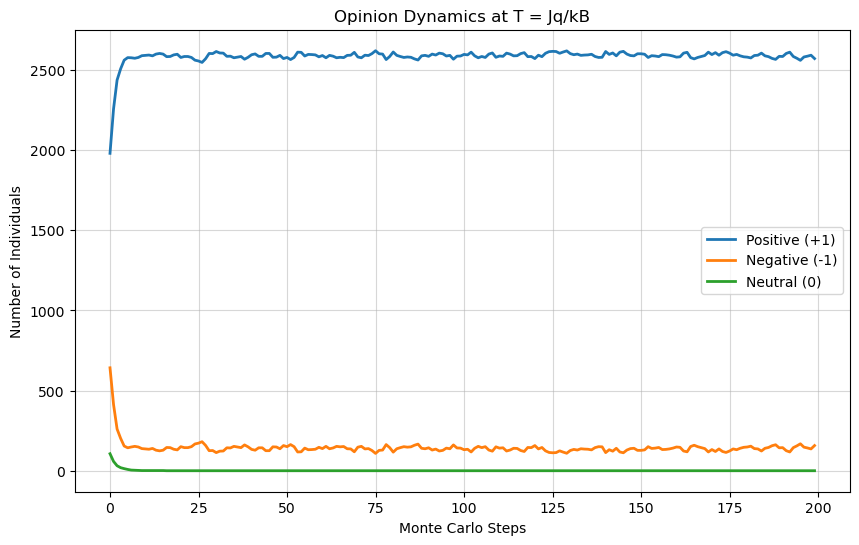

In [33]:
#OPINION DYNAMIC PLOT
plt.figure(figsize=(10, 6))
plt.plot(N_up_history, linewidth=2, label='Positive (+1)')
plt.plot(N_down_history, linewidth=2, label='Negative (-1)')
plt.plot(N_neutral_history, linewidth=2, label='Neutral (0)')
plt.title("Opinion Dynamics at T = Jq/kB")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Number of Individuals")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [34]:
Temperatures = [1, 2, 3]
M_T = {}
for T in Temperatures:
    np.random.seed(42)
    M_history_T, _, _, _,_ = simulate_glauber_with_data(N_up_initial=Data_N_up, N_down_initial=Data_N_down, N_o=Data_N_neutral,
        T=T, h_up=h_up, h_down=h_down, h_o=h_o, J=J_coupling, q=q_neighbors, steps=Time_steps)
    M_T[T] = M_history_T

INITIAL SPIN CONDITION
Total Population (N) : 2728
Probability +1       : 0.5220
Probability -1       : 0.4054
Probability 0        : 0.0726
Initial M            : 0.1166
Initial h            : 0.6716

RANDOM ASSIGN SPIN CONDITION
N_up       : 1424
N_down     : 1106
N_neutral  : 198
Actual M   : 0.1166

INITIAL SPIN CONDITION
Total Population (N) : 2728
Probability +1       : 0.5220
Probability -1       : 0.4054
Probability 0        : 0.0726
Initial M            : 0.1166
Initial h            : 0.6716

RANDOM ASSIGN SPIN CONDITION
N_up       : 1424
N_down     : 1106
N_neutral  : 198
Actual M   : 0.1166

INITIAL SPIN CONDITION
Total Population (N) : 2728
Probability +1       : 0.5220
Probability -1       : 0.4054
Probability 0        : 0.0726
Initial M            : 0.1166
Initial h            : 0.6716

RANDOM ASSIGN SPIN CONDITION
N_up       : 1424
N_down     : 1106
N_neutral  : 198
Actual M   : 0.1166



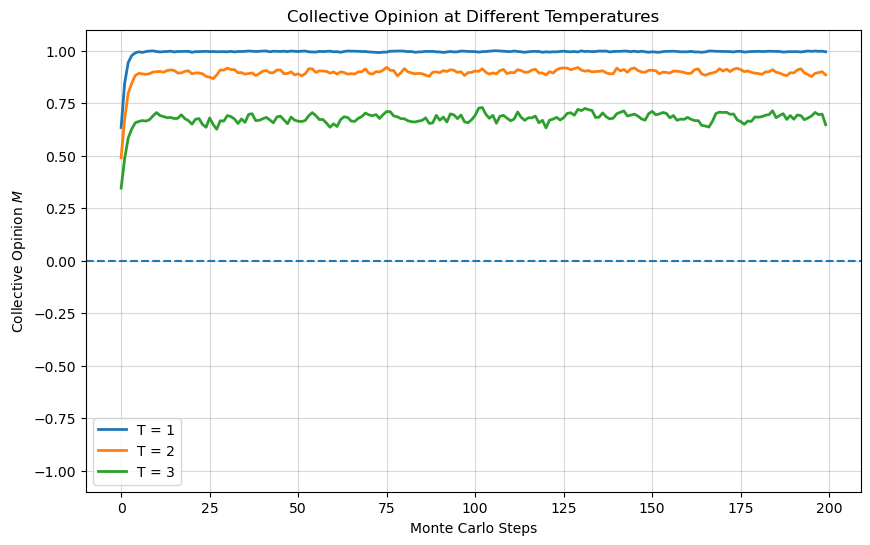

In [35]:
plt.figure(figsize=(10, 6))

for T in Temperatures:
    plt.plot( M_T[T], linewidth=2, label=f"T = {T}")

plt.title("Collective Opinion at Different Temperatures")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Collective Opinion $M$")
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--')
plt.legend()
plt.grid(True, alpha=0.5)

plt.show()

In [36]:
from IPython.display import HTML, display
import json
import numpy as np

# Prepare data
spin_data = [np.asarray(s).tolist() for s in spin_history]

N = len(spin_data[0])
grid_size = int(np.ceil(np.sqrt(N)))

M_data = np.asarray(M_history).tolist()

# HTML + JavaScript
html = f"""
<div style="font-family: Arial; width: 650px;">

    <h3>Opinion Evolution</h3>

    <canvas id="opinionCanvas"
            width="600"
            height="600"
            style="border:1px solid black;">
    </canvas>

    <br><br>

    <input
        type="range"
        id="timeSlider"
        min="0"
        max="{len(spin_data)-1}"
        value="0"
        step="1"
        style="width:600px;"
    >

    <br><br>

    <button id="playButton">
        ▶ Play
    </button>

    <p>
        MCS:
        <span id="mcsValue">0</span>
        &nbsp;&nbsp;&nbsp;
        M:
        <span id="magValue">---</span>
    </p>

</div>

<script>

(function(){{

    const spinData = {json.dumps(spin_data)};
    const magnetization = {json.dumps(M_data)};

    const canvas = document.getElementById("opinionCanvas");
    const ctx = canvas.getContext("2d");

    const slider = document.getElementById("timeSlider");
    const playButton = document.getElementById("playButton");

    const mcsText = document.getElementById("mcsValue");
    const magText = document.getElementById("magValue");

    const N = {N};
    const gridSize = {grid_size};

    let playing = false;
    let animationTimer = null;

    // =========================
    // Draw map
    // =========================

    function drawMap(mcs) {{

        const spins = spinData[mcs];

        ctx.clearRect(
            0,
            0,
            canvas.width,
            canvas.height
        );

        ctx.fillStyle = "white";

        ctx.fillRect(
            0,
            0,
            canvas.width,
            canvas.height
        );

        const cellSize = canvas.width / gridSize;

        for (let i = 0; i < N; i++) {{

            const row = Math.floor(i / gridSize);
            const col = i % gridSize;

            const x = col * cellSize;
            const y = row * cellSize;

            const spin = spins[i];

            if (spin === 1) {{
                ctx.fillStyle = "red";
            }}
            else if (spin === -1) {{
                ctx.fillStyle = "blue";
            }}
            else {{
                ctx.fillStyle = "lightgray";
            }}

            ctx.fillRect(
                x,
                y,
                cellSize,
                cellSize
            );
        }}

        mcsText.textContent = mcs;

        if (mcs < magnetization.length) {{
            magText.textContent =
                magnetization[mcs].toFixed(4);
        }}
        else {{
            magText.textContent = "---";
        }}
    }}

    // =========================
    // Slider
    // =========================

    slider.addEventListener(
        "input",
        function() {{
            drawMap(parseInt(this.value));
        }}
    );

    // =========================
    // Play / Pause
    // =========================

    playButton.addEventListener(
        "click",
        function() {{

            if (playing) {{

                // Pause
                playing = false;

                clearInterval(animationTimer);

                playButton.textContent = "▶ Play";

            }} else {{

                // Play
                playing = true;

                playButton.textContent = "⏸ Pause";

                animationTimer = setInterval(
                    function() {{

                        let current =
                            parseInt(slider.value);

                        if (current >= spinData.length - 1) {{

                            // Stop at the end
                            playing = false;

                            clearInterval(animationTimer);

                            playButton.textContent = "▶ Play";

                            return;
                        }}

                        current += 1;

                        slider.value = current;

                        drawMap(current);

                    }},
                    100
                );
            }}
        }}
    );

    // =========================
    // Initial map
    // =========================

    drawMap(0);

}})();

</script>
"""

display(HTML(html))